# Conversation-Style Data Analyst

### Project Blueprint

**What it does:**

User uploads any CSV → chats with data in plain English → LLM generates Pandas code → executes it → shows result + auto chart

### Architecture

###### User uploads CSV
        ↓
###### Pandas loads & profiles the data
        ↓
###### User asks a question in plain English
        ↓
###### LLM generates Pandas code to answer it
        ↓
###### Code executes safely in sandbox
        ↓
###### Result displayed as table + chart
        ↓
###### Conversation continues (memory of previous questions)

### Installing dependencies 


In [16]:
!pip install streamlit langchain langchain-groq  langchain-community groq plotly pandas

### Step 1 — Test Groq Connection + Load a CSV

In [8]:
import os
import numpy as np
os.environ["GROQ_API_KEY"] = "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"


In [2]:
import os
from dotenv import load_dotenv
import pandas as pd
from langchain_groq import ChatGroq
from langchain_core.messages import SystemMessage, HumanMessage

# Initialize LLM
llm = ChatGroq(
    api_key=os.getenv("GROQ_API_KEY"),
    model_name="llama-3.1-8b-instant",
    temperature=0
)

# Test connection
response = llm.invoke([HumanMessage(content="Reply with just: Groq connected successfully!")])
print(response.content)

Groq connected successfully!


In [3]:
# Load any CSV you have — sales data, student marks, anything works
# If you don't have one, we'll create a sample

df = pd.read_csv("synthetic_dataset.csv")  

# Auto profile the data
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nData Types:\n", df.dtypes)
print("\nSample Data:")
print(df.head())
print(df.isnull().sum())

Shape: (4362, 5)

Columns: ['Category', 'Price', 'Rating', 'Stock', 'Discount']

Data Types:
 Category     object
Price       float64
Rating      float64
Stock        object
Discount    float64
dtype: object

Sample Data:
  Category   Price    Rating         Stock  Discount
0      NaN  5548.0  1.870322           NaN       0.0
1      NaN  3045.0  4.757798           NaN      38.0
2      NaN  4004.0       NaN      In Stock       0.0
3      NaN  4808.0  1.492085           NaN      33.0
4      NaN  1817.0       NaN  Out of Stock      23.0
Category    2748
Price        174
Rating      2050
Stock       1352
Discount     392
dtype: int64


### Step 2 — Build the LLM Code Generator

In [6]:

def get_dataframe_context(df):
    """Give LLM full context about the dataframe"""
    context = f"""
You have access to a pandas DataFrame called `df` with the following structure:

Shape: {df.shape[0]} rows × {df.shape[1]} columns

Columns and Data Types:
{df.dtypes.to_string()}

Sample Data (first 3 rows):
{df.head(3).to_string()}

Missing Values per Column:
{df.isnull().sum().to_string()}

Numeric Column Statistics:
{df.describe().to_string()}

Unique values in categorical columns:
{chr(10).join([f"  {col}: {df[col].dropna().unique()[:10].tolist()}" for col in df.select_dtypes(include='object').columns])}
"""
    return context


def generate_pandas_code(question, df, llm):
    """Ask LLM to generate Pandas code for the question"""
    
    context = get_dataframe_context(df)
    
    messages = [
        SystemMessage(content=f"""You are an expert data analyst who writes precise Pandas code.

{context}

STRICT RULES:
1. Always write code that works on the DataFrame `df`
2. Store your final result in a variable called `result`
3. `result` must be either: a DataFrame, a Series, a scalar value, or a dict
4. Do NOT use print() statements
5. Do NOT import any libraries — pandas (pd) and numpy (np) are already imported
6. Handle missing values gracefully using dropna() or fillna() where needed
7. Write ONLY the Python code — no explanation, no markdown, no backticks
8. Keep the code simple and correct"""),

        HumanMessage(content=f"Question: {question}\n\nWrite the Pandas code to answer this:")
    ]
    
    response = llm.invoke(messages)
    code = response.content.strip()
    
    # Clean up any markdown code blocks if LLM adds them
    if "```python" in code:
        code = code.split("```python")[1].split("```")[0].strip()
    elif "```" in code:
        code = code.split("```")[1].split("```")[0].strip()
    
    return code


# Test it
question = "What are the unique categories in the dataset?"
code = generate_pandas_code(question, df, llm)

print(code)

result = df['Category'].dropna().unique()


### Step 3 — Safe Code Executor

In [9]:
import traceback

def execute_code(code, df):
    """Safely execute LLM-generated Pandas code and return result"""
    
    # Safe execution environment — only expose what's needed
    local_vars = {
        "df": df.copy(),
        "pd": pd,
        "np": np,
        "result": None
    }
    
    try:
        exec(code, {"__builtins__": {}}, local_vars)
        result = local_vars.get("result", None)
        
        if result is None:
            return None, "⚠️ Code ran but no `result` variable was set."
        
        return result, None  # result, error
    
    except Exception as e:
        error_msg = traceback.format_exc()
        return None, f"❌ Execution Error:\n{error_msg}"


def ask_data(question, df, llm):
    """Full pipeline: question → code → execute → return result"""
    
    # Step 1: Generate code
    code = generate_pandas_code(question, df, llm)
    
    # Step 2: Execute code
    result, error = execute_code(code, df)
    
    if error:
        # Ask LLM to fix the code once
        fix_messages = [
            SystemMessage(content="You are a Python expert. Fix the following Pandas code that threw an error. Return ONLY the corrected code, no explanation."),
            HumanMessage(content=f"Original code:\n{code}\n\nError:\n{error}\n\nFixed code:")
        ]
        fixed_code = llm.invoke(fix_messages).content.strip()
        if "```python" in fixed_code:
            fixed_code = fixed_code.split("```python")[1].split("```")[0].strip()
        
        result, error = execute_code(fixed_code, df)
        code = fixed_code  # use the fixed version
    
    return result, code, error


# ── Test it with 3 questions ──────────────────────────────
test_questions = [
    "What is the average price for each category?",
    "How many products are Out of Stock?",
    "Which category has the highest average rating?"
]

for q in test_questions:
    print(f"\n❓ {q}")
    result, code, error = ask_data(q, df, llm)
    print(f"📝 Code: {code}")
    print(f"✅ Result: {result}")
    print("-" * 50)


❓ What is the average price for each category?
📝 Code: result = df.groupby('Category', dropna=False)['Price'].mean()
✅ Result: Category
A      4782.910026
B      5410.330623
C      5086.802500
D      5032.468672
NaN    4983.440897
Name: Price, dtype: float64
--------------------------------------------------

❓ How many products are Out of Stock?
📝 Code: result = df['Stock'].value_counts()['Out of Stock']
✅ Result: 1497
--------------------------------------------------

❓ Which category has the highest average rating?
📝 Code: result = df.groupby('Category', dropna=False)['Rating'].mean().sort_values(ascending=False).head(1)
✅ Result: Category
D    3.116892
Name: Rating, dtype: float64
--------------------------------------------------


### Step 4 — Auto Chart Generator

Chart type chosen: bar


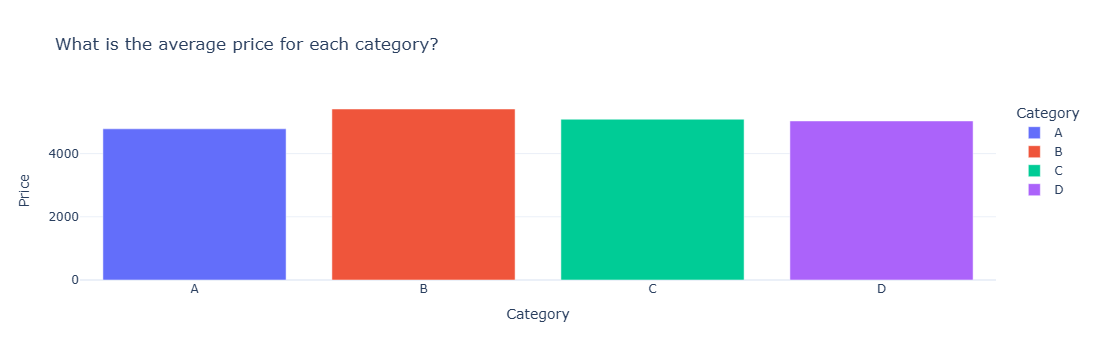

In [10]:
import plotly.express as px
import plotly.graph_objects as go

def generate_chart(result, question, llm):
    """Decide chart type and generate Plotly chart from result"""
    
    # Ask LLM what chart type fits best
    chart_decision = llm.invoke([
        SystemMessage(content="""You are a data visualization expert.
Given a question and result type, decide the best chart.
Reply with ONLY one word from: bar, line, pie, scatter, histogram, table, none
- bar: comparisons across categories
- line: trends over time
- pie: proportions/percentages
- scatter: relationship between two numeric columns
- histogram: distribution of a single numeric column
- table: when result is a single value or complex dataframe
- none: if result is a scalar number"""),
        HumanMessage(content=f"Question: {question}\nResult type: {type(result).__name__}\nResult preview: {str(result)[:300]}")
    ]).content.strip().lower()

    fig = None

    try:
        # Bar chart
        if chart_decision == "bar":
            if hasattr(result, 'reset_index'):
                plot_df = result.reset_index()
                plot_df.columns = [str(c) for c in plot_df.columns]
                fig = px.bar(
                    plot_df,
                    x=plot_df.columns[0],
                    y=plot_df.columns[1],
                    title=question,
                    color=plot_df.columns[0],
                    template="plotly_white"
                )

        # Pie chart
        elif chart_decision == "pie":
            if hasattr(result, 'reset_index'):
                plot_df = result.reset_index()
                plot_df.columns = [str(c) for c in plot_df.columns]
                fig = px.pie(
                    plot_df,
                    names=plot_df.columns[0],
                    values=plot_df.columns[1],
                    title=question,
                    template="plotly_white"
                )

        # Line chart
        elif chart_decision == "line":
            if hasattr(result, 'reset_index'):
                plot_df = result.reset_index()
                plot_df.columns = [str(c) for c in plot_df.columns]
                fig = px.line(
                    plot_df,
                    x=plot_df.columns[0],
                    y=plot_df.columns[1],
                    title=question,
                    template="plotly_white",
                    markers=True
                )

        # Histogram
        elif chart_decision == "histogram":
            if hasattr(result, 'values'):
                fig = px.histogram(
                    x=result.values,
                    title=question,
                    template="plotly_white",
                    labels={"x": str(result.name) if hasattr(result, 'name') else "Value"}
                )

        # Scatter
        elif chart_decision == "scatter":
            if hasattr(result, 'reset_index'):
                plot_df = result.reset_index()
                plot_df.columns = [str(c) for c in plot_df.columns]
                fig = px.scatter(
                    plot_df,
                    x=plot_df.columns[0],
                    y=plot_df.columns[1],
                    title=question,
                    template="plotly_white"
                )

    except Exception as e:
        print(f"Chart generation skipped: {e}")
        fig = None

    return fig, chart_decision


# ── Test chart generation ─────────────────────────────────
test_q = "What is the average price for each category?"
result, code, error = ask_data(test_q, df, llm)

fig, chart_type = generate_chart(result, test_q, llm)

print(f"Chart type chosen: {chart_type}")
if fig:
    fig.show()
else:
    print("No chart generated — result shown as table")

### Step 5 — Conversation Memory

In [11]:
def ask_data_with_memory(question, df, llm, chat_history):
    """Full pipeline with conversation memory"""
    
    context = get_dataframe_context(df)
    
    # Build history string for context
    history_text = ""
    if chat_history:
        history_text = "\n\nPrevious conversation:\n"
        for turn in chat_history[-4:]:  # last 4 turns only to stay within token limit
            history_text += f"User asked: {turn['question']}\n"
            history_text += f"Result was: {str(turn['result'])[:200]}\n\n"
    
    messages = [
        SystemMessage(content=f"""You are an expert data analyst who writes precise Pandas code.

{context}
{history_text}

STRICT RULES:
1. Always write code that works on the DataFrame `df`
2. Store your final result in a variable called `result`
3. `result` must be either: a DataFrame, a Series, a scalar value, or a dict
4. Do NOT use print() statements
5. Do NOT import any libraries — pandas (pd) and numpy (np) are already imported
6. Handle missing values gracefully using dropna() or fillna() where needed
7. Write ONLY the Python code — no explanation, no markdown, no backticks
8. If the question refers to previous results, use the context above"""),

        HumanMessage(content=f"Question: {question}\n\nWrite the Pandas code:")
    ]
    
    # Generate code
    response = llm.invoke(messages)
    code = response.content.strip()
    if "```python" in code:
        code = code.split("```python")[1].split("```")[0].strip()
    elif "```" in code:
        code = code.split("```")[1].split("```")[0].strip()
    
    # Execute
    result, error = execute_code(code, df)
    
    # Auto fix if error
    if error:
        fix_messages = [
            SystemMessage(content="Fix this Pandas code. Return ONLY corrected code, no explanation."),
            HumanMessage(content=f"Code:\n{code}\n\nError:\n{error}\n\nFixed:")
        ]
        fixed_code = llm.invoke(fix_messages).content.strip()
        if "```python" in fixed_code:
            fixed_code = fixed_code.split("```python")[1].split("```")[0].strip()
        result, error = execute_code(fixed_code, df)
        code = fixed_code
    
    # Save to history
    if result is not None:
        chat_history.append({
            "question": question,
            "code": code,
            "result": result,
            "error": error
        })
    
    return result, code, error, chat_history


# ── Test conversation memory ──────────────────────────────
chat_history = []

questions = [
    "What is the average discount per category?",
    "Which of those categories has the most products?",  # refers to previous answer
    "What is the price range for that category?"         # refers to previous answer
]

for q in questions:
    print(f"\n❓ {q}")
    result, code, error, chat_history = ask_data_with_memory(q, df, llm, chat_history)
    if error:
        print(f"❌ Error: {error}")
    else:
        print(f"✅ Result: {result}")
    print("-" * 50)

print(f"\n💬 Total conversation turns stored: {len(chat_history)}")


❓ What is the average discount per category?
✅ Result: Category
A      25.403846
B      24.016949
C      24.311688
D      25.346369
NaN    24.371463
Name: Discount, dtype: float64
--------------------------------------------------

❓ Which of those categories has the most products?
✅ Result: Category
C    425
D    408
A    403
B    378
Name: count, dtype: int64
--------------------------------------------------

❓ What is the price range for that category?
✅ Result:             min     max
Category               
A         108.0  9997.0
B         107.0  9919.0
C         126.0  9974.0
D         112.0  9988.0
NaN       102.0  9999.0
--------------------------------------------------

💬 Total conversation turns stored: 3


### Step 6 : Build The Streamlit app

Let's have a file 'app.py' that builds the streamlit app.